In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
sys.path.append("../src")

from _visualization import *
import _mapping
import matplotlib.pyplot as plt
import numpy as np

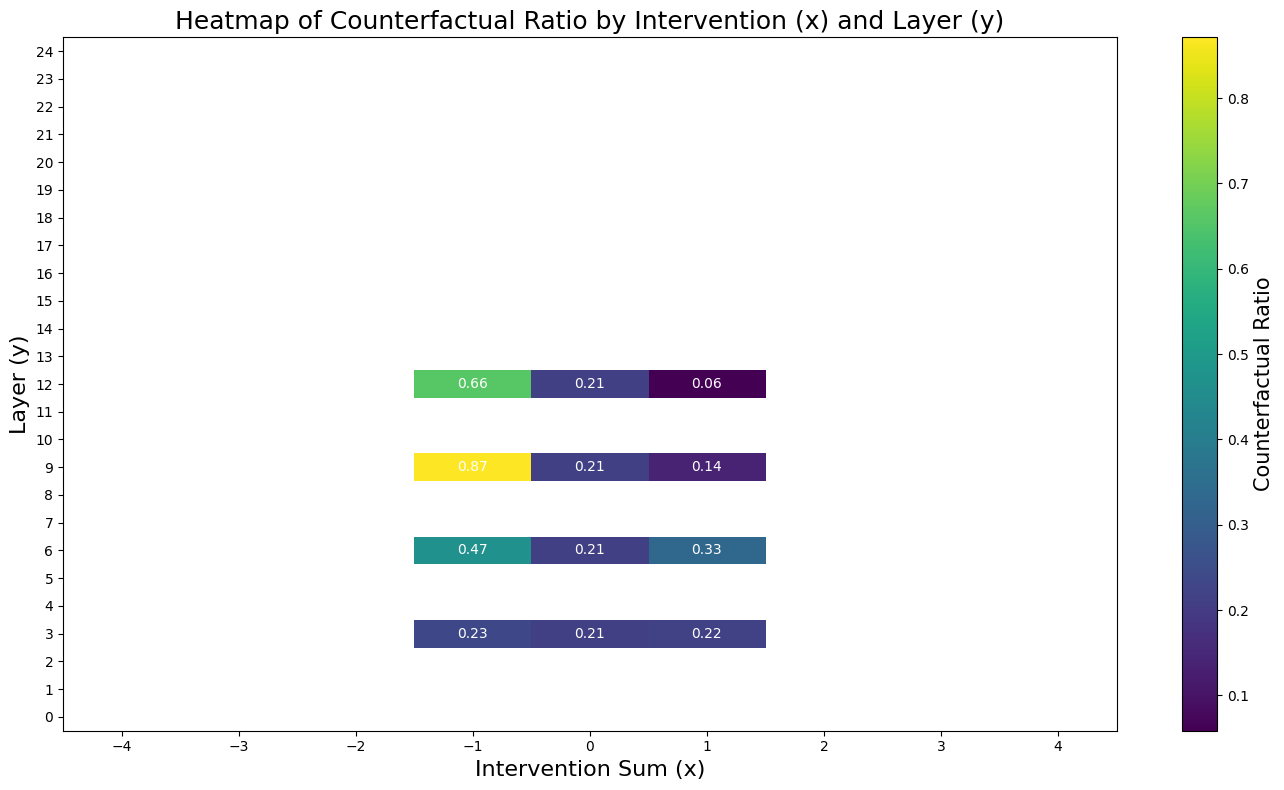

In [8]:
plot_intervention_effect_heatmap("../experiments/steering/output/GPT-OSS_stepwise/steering", "intervention_effect")

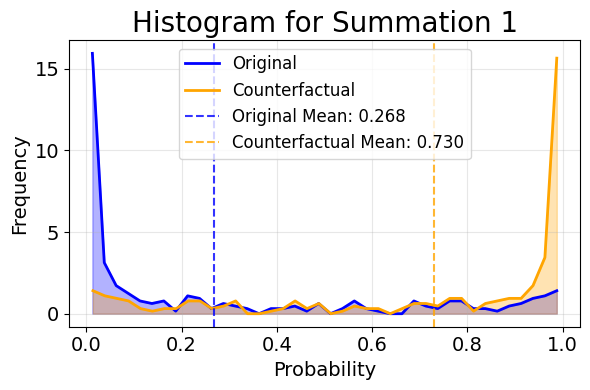

In [3]:
probability_filepath = "../experiments/attention_heads/output/GPT-OSS_stepwise/geometric_heads/patch_top_64_operand_1_1_prob_h_pre_penultimate_sum.csv"
plot_prediction_probability_histogram_integrated(probability_filepath, "Summation 1")

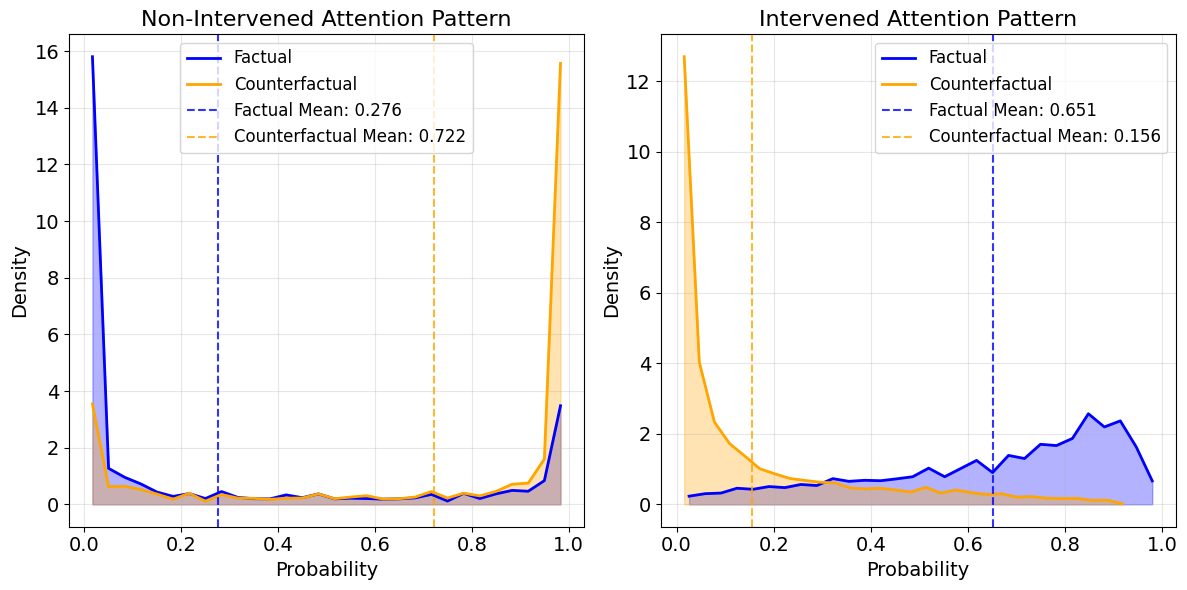

In [4]:
probability_filepath = "../experiments/activation_intervention/output/GPT-OSS_stepwise/frozen_attention_intervened_pattern/non_intervened_pattern_h_pre_penultimate_sum_.csv"
probability_filepath_2 = "../experiments/activation_intervention/output/GPT-OSS_stepwise/frozen_attention_intervened_pattern/h_pre_penultimate_sum_.csv"
plot_two_prediction_probability_distributions_integrated(probability_filepath, probability_filepath_2)

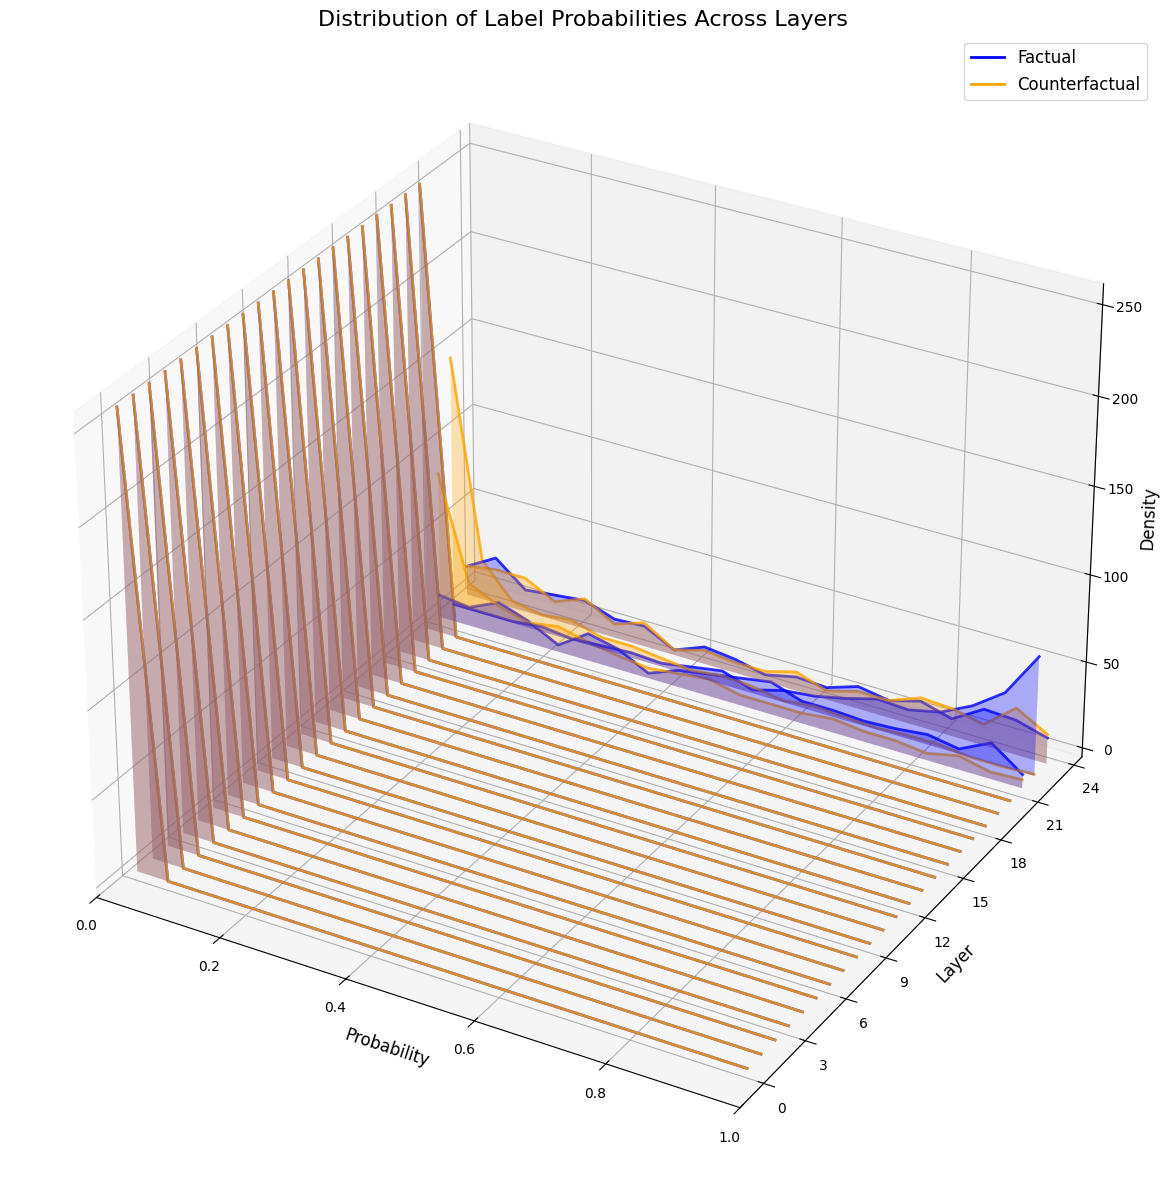

In [29]:
probability_filepath = "../experiments/token_intervention/output/GPT-OSS_stepwise/logit_lens/h_pre_result_final_sum_-1.csv"
# probability_filepath = "../experiments/activation_intervention/output/GPT-OSS_stepwise/layerwise/h_pre_penultimate_sum_.csv"
plot_prediction_probability_distributions_integrated_layerwise(probability_filepath, range(24))

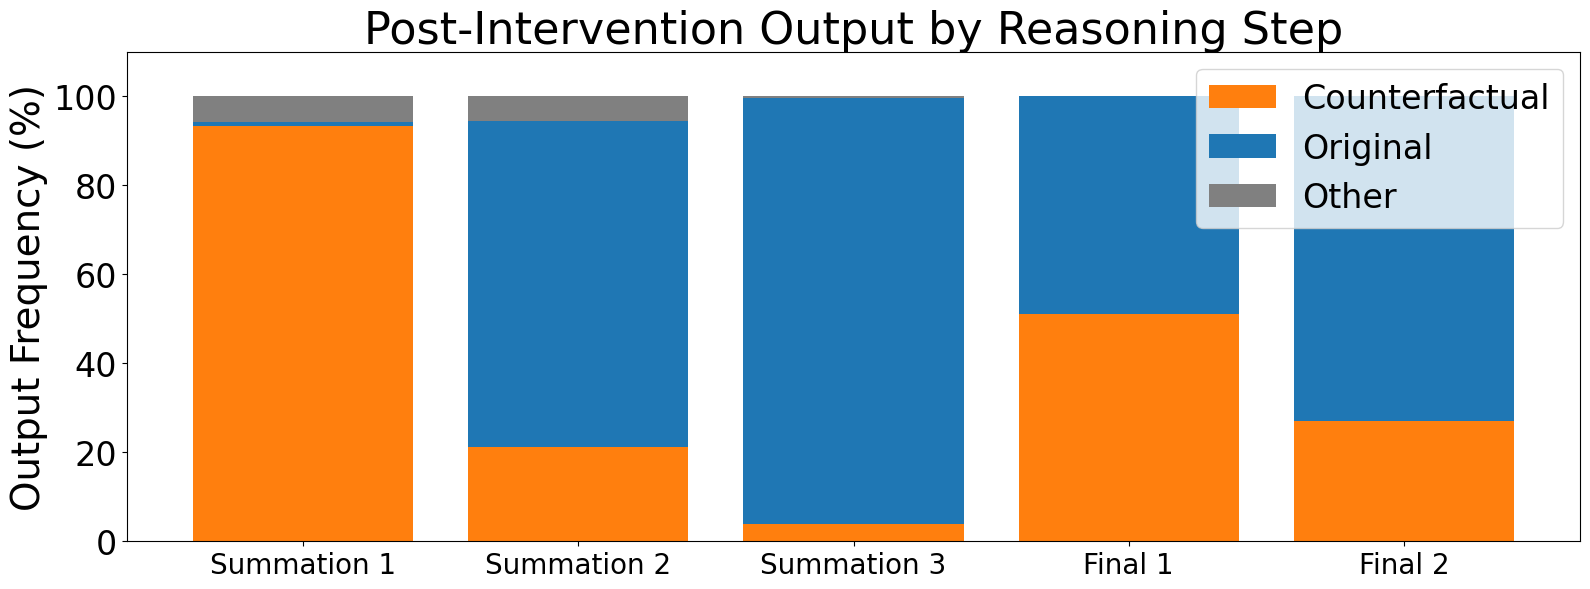

In [15]:
# Create figure
fig, ax = plt.subplots(figsize=(16, 6))

# Data for the stacked bar chart
categories = ['Summation 1', 'Summation 2', 'Summation 3', 'Final 1', 'Final 2']
counterfactual_values = [93.4, 21.1, 3.9, 51.2, 26.95]
original_values = [0.8, 73.4, 95.7, 48.8, 73.05]
other_values = [5.8, 5.5, 0.4, 0, 0]

# Colors for the three segments
colors = ['#ff7f0e', '#1f77b4', '#808080']

# Create the stacked bars
bars1 = ax.bar(categories, counterfactual_values, color=colors[0], label='Counterfactual')
bars2 = ax.bar(categories, original_values, bottom=counterfactual_values, color=colors[1], label='Original')
bars3 = ax.bar(categories, other_values, bottom=np.array(counterfactual_values) + np.array(original_values), color=colors[2], label='Other')

# Customize the chart
ax.set_ylabel('Output Frequency (%)', fontsize=28)
ax.set_title('Post-Intervention Output by Reasoning Step', fontsize=32)
ax.set_ylim(0, 110)
ax.legend(loc='upper right', fontsize=24)
ax.tick_params(axis='y', which='major', labelsize=24)
ax.tick_params(axis='x', which='major', labelsize=20)

# # Add value labels on each segment
# for i, (counterfactual, original, other) in enumerate(zip(counterfactual_values, original_values, other_values)):
#     # Bottom segment label
#     ax.text(i, max(counterfactual/2, 8), f"{counterfactual:.1f}%", ha='center', va='center', fontweight='bold', color='white')
    # # Middle segment label
    # ax.text(i, counterfactual + original/2, str(original), ha='center', va='center', fontweight='bold')
    # # Top segment label
    # ax.text(i, counterfactual + original + other/2, str(other), ha='center', va='center', fontweight='bold')

# Save the figure as SVG
plt.savefig('../figures/post_intervention_output_by_reasoning_step.svg', format='svg', bbox_inches='tight', dpi=300)


plt.tight_layout()
plt.show()

In [52]:
def plot_intervention_results_by_directory(directory_path):
    import os
    import pandas as pd
    
    # Get all CSV files in the directory
    csv_files = [f for f in os.listdir(directory_path) if f.endswith('.csv')]
    
    # Sort files by their numeric prefix
    csv_files.sort(key=lambda x: int(x.split('_')[0]) if x.split('_')[0].isdigit() else float('inf'))
    
    # Process each file to get categories and values
    categories = []
    counterfactual_values = []
    original_values = []
    other_values = []
    
    for file in csv_files:
        # Create category name from filename, removing numeric prefix and .csv extension
        parts = file.replace('.csv', '').split('_')
        if parts[0].isdigit():
            # Remove the numeric prefix
            category = '_'.join(parts[1:])
        else:
            category = '_'.join(parts)
        
        # Replace underscores with spaces for display
        category = category.replace('_', ' ')
        categories.append(category)
        
        # Get accuracy results for this file
        file_path = os.path.join(directory_path, file)
        accuracy_results = get_accuracy(file_path, output_type="immediate")
        
        # Calculate percentages
        total_rows = len(accuracy_results)
        counterfactual_count = accuracy_results['is_counterfactual'].sum()
        factual_count = accuracy_results['is_factual'].sum()
        other_count = total_rows - counterfactual_count - factual_count
        
        counterfactual_pct = (counterfactual_count / total_rows) * 100
        original_pct = (factual_count / total_rows) * 100
        other_pct = (other_count / total_rows) * 100
        
        counterfactual_values.append(counterfactual_pct)
        original_values.append(original_pct)
        other_values.append(other_pct)
    
    # Create figure
    fig, ax = plt.subplots(figsize=(17, 6))
    
    # Colors for the three segments
    colors = ['#ff7f0e', '#1f77b4', '#808080']
    
    # Create the stacked bars
    bars1 = ax.bar(categories, counterfactual_values, color=colors[0], label='Counterfactual')
    bars2 = ax.bar(categories, original_values, bottom=counterfactual_values, color=colors[1], label='Original')
    bars3 = ax.bar(categories, other_values, bottom=np.array(counterfactual_values) + np.array(original_values), color=colors[2], label='Other')
    
    # Customize the chart
    ax.set_ylabel('Output Frequency (%)', fontsize=28)
    ax.set_title('Post-Intervention Output by Reasoning Step', fontsize=32)
    ax.set_ylim(0, 110)
    ax.legend(loc='upper right', fontsize=24)
    ax.tick_params(axis='both', which='major', labelsize=24)
    
    plt.tight_layout()
    plt.show()

Total rows: 256
Factual answers: 0
Counterfactual answers: 256
Factual accuracy: 0.00%
Counterfactual accuracy: 100.00%
Total rows: 5120
Factual answers: 1367
Counterfactual answers: 3751
Factual accuracy: 26.70%
Counterfactual accuracy: 73.26%
Total rows: 5120
Factual answers: 4528
Counterfactual answers: 592
Factual accuracy: 88.44%
Counterfactual accuracy: 11.56%
Total rows: 80
Factual answers: 72
Counterfactual answers: 8
Factual accuracy: 90.00%
Counterfactual accuracy: 10.00%
Total rows: 256
Factual answers: 109
Counterfactual answers: 146
Factual accuracy: 42.58%
Counterfactual accuracy: 57.03%
Total rows: 4100
Factual answers: 3953
Counterfactual answers: 130
Factual accuracy: 96.41%
Counterfactual accuracy: 3.17%


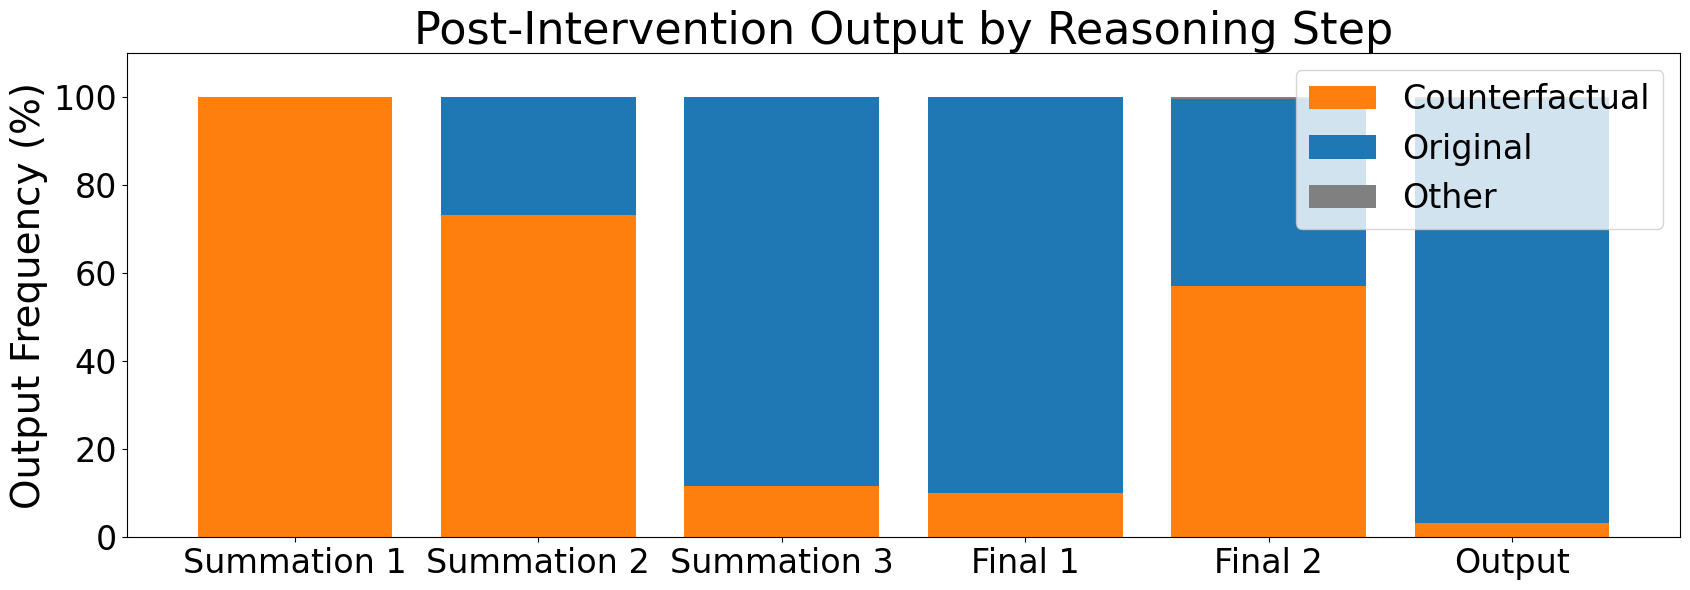

In [54]:
plot_intervention_results_by_directory("../experiments/activation_intervention/output/GPT-OSS_stepwise/clean_pattern")

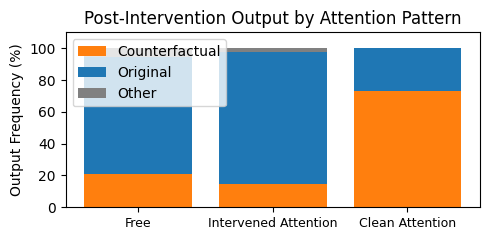

In [57]:
# Create figure
fig, ax = plt.subplots(figsize=(5, 2.5))

# Data for the stacked bar chart
categories = ['Free', 'Intervened Attention', 'Clean Attention']
counterfactual_values = [21.1, 14.7, 73.3]
original_values = [73.4, 83.1, 26.7]
other_values = [5.5, 2.2, 0]

# Colors for the three segments
colors = ['#ff7f0e', '#1f77b4', '#808080']

# Create the stacked bars
bars1 = ax.bar(categories, counterfactual_values, color=colors[0], label='Counterfactual')
bars2 = ax.bar(categories, original_values, bottom=counterfactual_values, color=colors[1], label='Original')
bars3 = ax.bar(categories, other_values, bottom=np.array(counterfactual_values) + np.array(original_values), color=colors[2], label='Other')

# Customize the chart
ax.set_ylabel('Output Frequency (%)')
ax.set_title('Post-Intervention Output by Attention Pattern')
ax.set_ylim(0, 110)
ax.legend(loc='upper left')
ax.tick_params(axis='x', labelsize=9)

# # Add value labels on each segment
# for i, (counterfactual, original, other) in enumerate(zip(counterfactual_values, original_values, other_values)):
#     # Bottom segment label
#     ax.text(i, max(counterfactual/2, 8), f"{counterfactual:.1f}%", ha='center', va='center', fontweight='bold', color='white')
    # # Middle segment label
    # ax.text(i, counterfactual + original/2, str(original), ha='center', va='center', fontweight='bold')
    # # Top segment label
    # ax.text(i, counterfactual + original + other/2, str(other), ha='center', va='center', fontweight='bold')

# Save the figure as SVG
fig.savefig('../figures/attention-pattern.svg', format='svg', bbox_inches='tight')

plt.tight_layout()
plt.show()

Total rows: 256
Factual answers: 256
Counterfactual answers: 0
Factual accuracy: 100.00%
Counterfactual accuracy: 0.00%


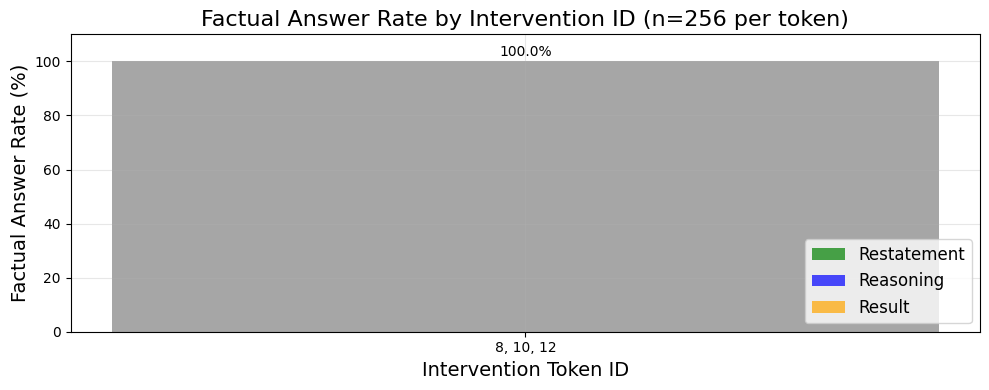


Detailed Statistics by Intervention ID:
Intervention success rate ratios:
  Intervention ID 8, 10, 12: 0.0% intervention success rate (n=256)


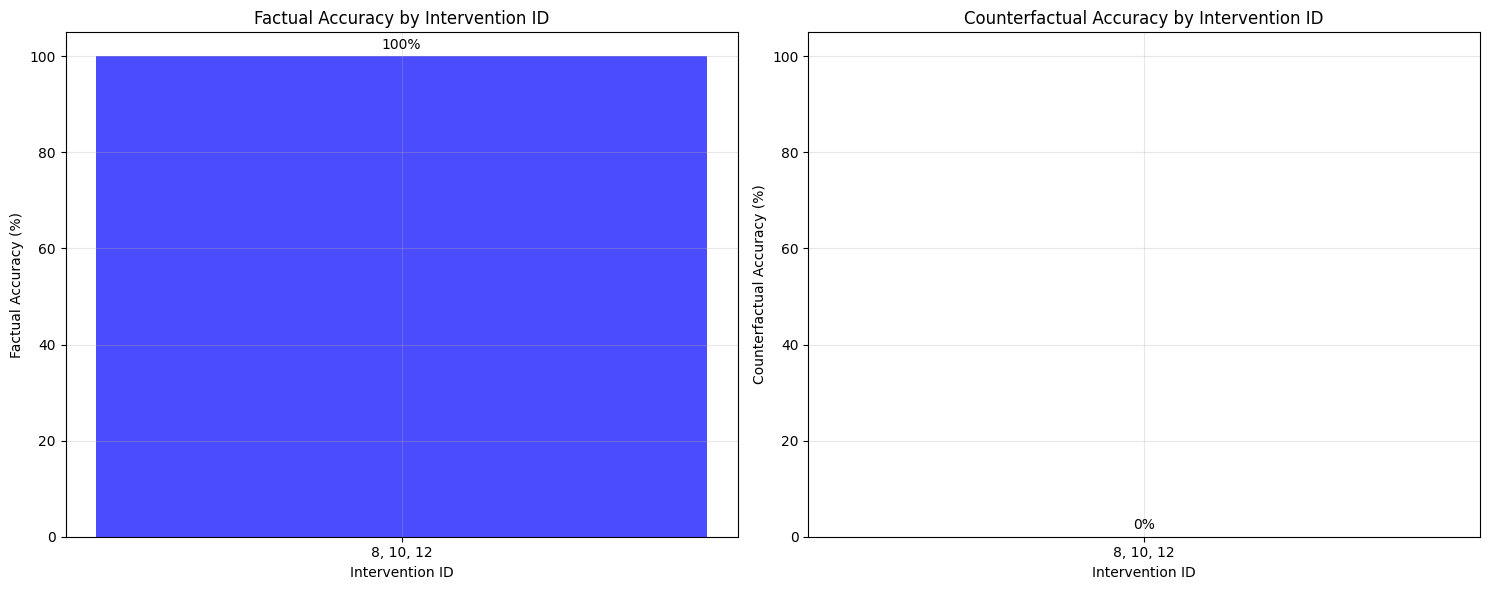


Detailed Statistics by Intervention ID:
Factual accuracy ratios:
  Intervention ID 8, 10, 12: 100.0% factual accuracy (n=256)

Counterfactual accuracy ratios:
  Intervention ID 8, 10, 12: 0.0% counterfactual accuracy (n=256)


In [9]:
accuracy_results = get_accuracy("../experiments/token_intervention/output/GPT-OSS_stepwise/result_unfaithful_source/h_pre_penultimate_sum_8_10_12.csv", output_type="immediate")
# accuracy_results = get_accuracy("../experiments/token_intervention/output/GPT-OSS_stepwise/generation_h.csv", output_type="final_output")
plot_intervention_success_rate_by_location(accuracy_results, _mapping.intervene_ids_stepwise_3_digit_h)
plot_intervention_results_by_location(accuracy_results)

Total rows: 6144
Factual answers: 2756
Counterfactual answers: 2531
Factual accuracy: 44.86%
Counterfactual accuracy: 41.19%
Counterfactual bar heights by layer:
Layer 0: 7.81%
Layer 1: 7.03%
Layer 2: 21.88%
Layer 3: 23.05%
Layer 4: 34.38%
Layer 5: 55.86%
Layer 6: 82.81%
Layer 7: 82.03%
Layer 8: 70.70%
Layer 9: 70.31%
Layer 10: 68.36%
Layer 11: 64.45%
Layer 12: 60.16%
Layer 13: 58.59%
Layer 14: 56.25%
Layer 15: 53.91%
Layer 16: 51.56%
Layer 17: 48.44%
Layer 18: 36.72%
Layer 19: 34.38%
Layer 20: 0.00%
Layer 21: 0.00%
Layer 22: 0.00%
Layer 23: 0.00%


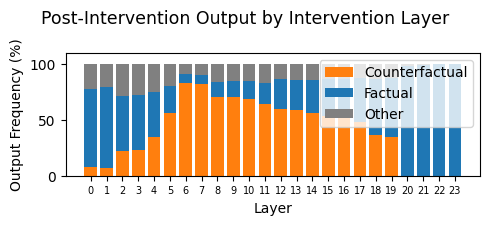

In [49]:
accuracy_results = get_accuracy("../experiments/activation_intervention/output/GPT-OSS_stepwise/vanilla_layer/2_digit_restatement_layerwise.csv", output_type="immediate")
plot_intervention_success_rate_layerwise(accuracy_results)

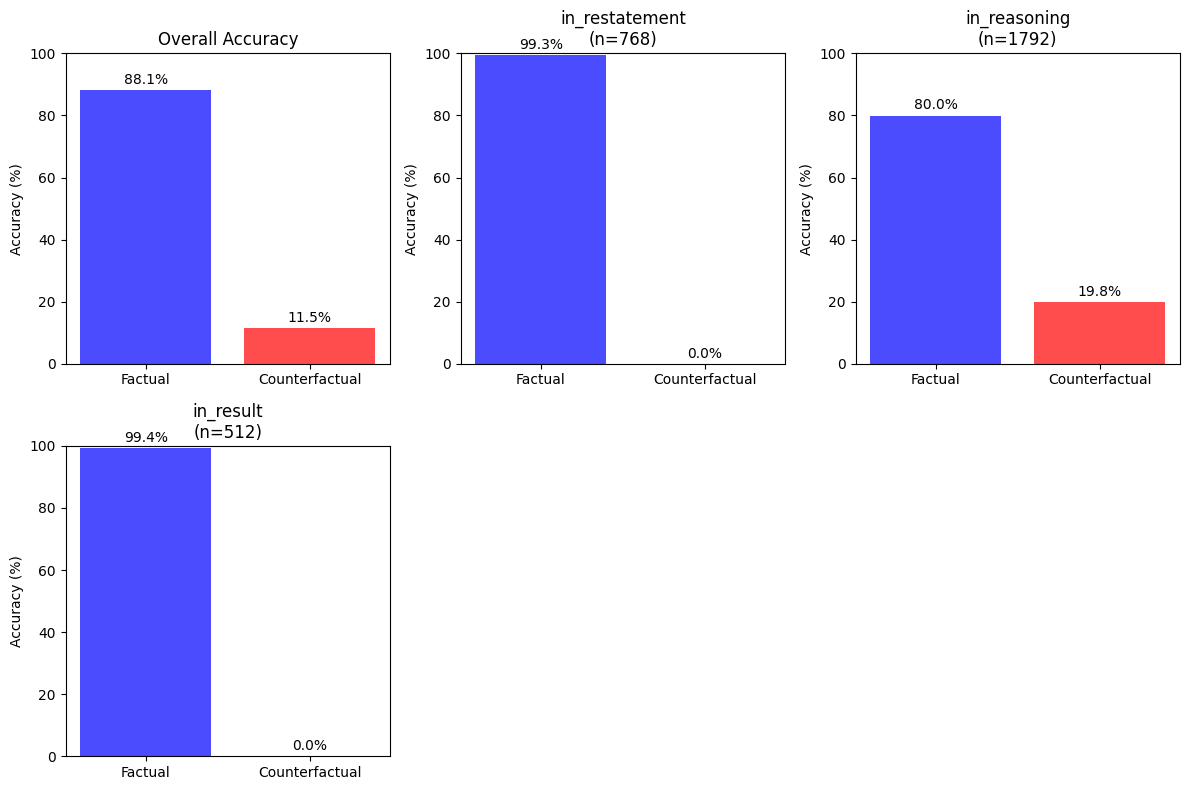


Detailed Statistics:
Overall - Factual: 88.05%, Counterfactual: 11.52%
in_restatement - Factual: 99.35%, Counterfactual: 0.00% (n=768)
in_reasoning - Factual: 79.97%, Counterfactual: 19.75% (n=1792)
in_result - Factual: 99.41%, Counterfactual: 0.00% (n=512)


In [24]:
plot_intervention_results_by_type(accuracy_results)

Has wait but no answer in generated text:  , 487 + 90 = 577, 577 + 1 = 578. Or do column addition: 7+1=8, 8+9=17, carry 1, 3+3+1=7, 3+3=6? Wait, let's do properly: 387 + 391: units: 7+1=8. Tens: 8+9=17, write 7 carry 1. Hundreds: 3+3+1=7. So 578. So the sum is 578. In final, just output 578.<|end|><|start|>assistant<|channel|>final<|message|>578<|return|>
Has wait but no answer in generated text:  ? Wait, 159 + 400 = 559? Actually 159 + 400 = 559? Let's check: 159 + 400 = 559? 159 + 400 = 559? Wait, 159 + 400 = 559? That seems wrong. Let's do it carefully: 159 + 400 = 559? 159 + 400 = 559? Wait, 159 + 400 = 559? That seems wrong. Let's do it: 159 + 400 = 559? Actually 159 + 400 = 559? Let's do it: 159 + 400 = 559? Wait, 159 + 400 = 559? That seems wrong. Let's do it: 159 + 400 = 559? Wait, 159 + 400 = 559? I'm repeating. Let's do it properly: 159 + 400 = 559? Wait, 159 + 400 = 559? That is wrong. Let's do it: 159 + 400 = 559? Wait, 159 + 400 = 559? I'm stuck. Let's do it: 159 + 400 = 5

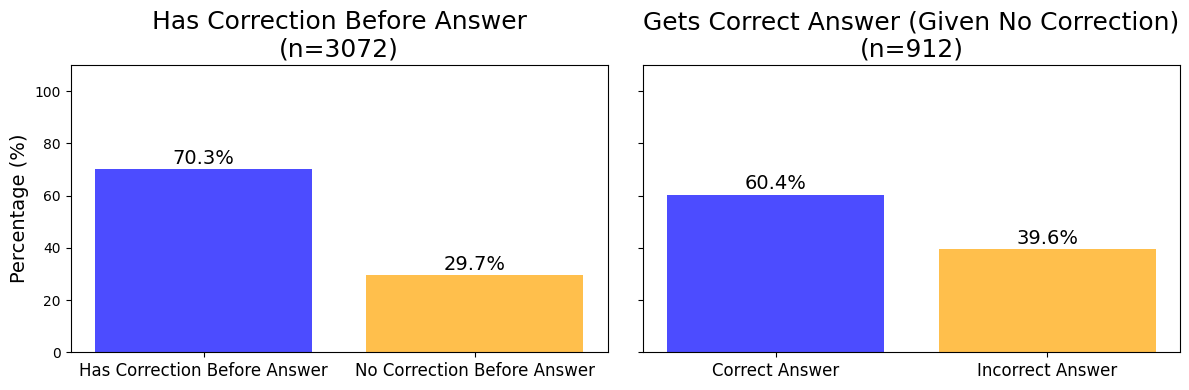

In [166]:
plot_wait_ratio_simplified(accuracy_results)

In [14]:
# Print rows where in_restatement is True and has_wait_before_answer is 0
filtered_rows = accuracy_results[(accuracy_results['in_reasoning'] == True) & (accuracy_results['has_wait_before_answer'] == 2)].sort_values('intervention_id')
# filtered_rows = filtered_rows[~filtered_rows['generated_text'].str.contains('\?', regex=True)]

print(f"Found {len(filtered_rows)} rows where in_reasoning is True and has_wait_before_answer is 2:")
print("=" * 80)

for idx, row in filtered_rows.iterrows():
    print(f"Row {idx}:")
    print(f"  base_1_num: {row['base_1_num']}")
    print(f"  base_2_num: {row['base_2_num']}")
    print(f"  base_sum: {row['base_sum']}")
    print(f"  intervention_id: {row['intervention_id']}")
    print(f"  is_factual: {row['is_factual']}")
    print(f"  is_counterfactual: {row['is_counterfactual']}")
    print(f"  generated_text: {row['generated_text'][:200]}...")  # First 200 chars
    print("-" * 40)


Found 359 rows where in_reasoning is True and has_wait_before_answer is 2:
Row 1683:
  base_1_num: 131
  base_2_num: 842
  base_sum: 973
  intervention_id: 14
  is_factual: False
  is_counterfactual: False
  generated_text:  = 231, + 700 = 931, + 100 = 1031, + 40 = 1071, + 2 = 1073. Or do column addition: 131 + 842 = 1073. So final output: 1073.<|end|><|start|>assistant<|channel|>final<|message|>1073<|return|>...
----------------------------------------
Row 664:
  base_1_num: 167
  base_2_num: 494
  base_sum: 661
  intervention_id: 18
  is_factual: False
  is_counterfactual: True
  generated_text:  = 267, then 267 + 90 = 357, then 357 + 4 = 361. Or do column addition: 167 + 494 = 361. So the sum is 361. In final, output only "361".<|end|><|start|>assistant<|channel|>final<|message|>361<|return|...
----------------------------------------
Row 5:
  base_1_num: 204
  base_2_num: 443
  base_sum: 647
  intervention_id: 19
  is_factual: False
  is_counterfactual: True
  generated_text: , 404

In [14]:
import pandas as pd

# Read both CSV files
token_df = pd.read_csv("../experiments/token_intervention/output/R1/fixed_reasoning_h_pre_result.csv")
activation_df = pd.read_csv("../experiments/activation_intervention/output/R1/layer_0_h_pre_result.csv")

# Compare generated_text entries and print differences
print("Rows where generated_text differs between token and activation intervention:")
print("=" * 70)

for i in range(min(len(token_df), len(activation_df))):
    token_text = token_df.iloc[i]['generated_text']
    activation_text = activation_df.iloc[i]['generated_text']
    
    if token_text != activation_text:
        base_1_num = token_df.iloc[i]['base_1_num']
        base_2_num = token_df.iloc[i]['base_2_num']
        intervention_id = token_df.iloc[i]['intervention_id']
        print(f"Row {i}: base_1_num={base_1_num}, base_2_num={base_2_num}, intervention_id={intervention_id}")

# Also check if the files have different lengths
if len(token_df) != len(activation_df):
    print(f"\nNote: Files have different lengths - Token: {len(token_df)}, Activation: {len(activation_df)}")


Rows where generated_text differs between token and activation intervention:
Row 11: base_1_num=201, base_2_num=337, intervention_id=13
Row 33: base_1_num=136, base_2_num=652, intervention_id=4
Row 51: base_1_num=629, base_2_num=235, intervention_id=4
Row 60: base_1_num=267, base_2_num=213, intervention_id=4
Row 61: base_1_num=267, base_2_num=213, intervention_id=12
Row 62: base_1_num=267, base_2_num=213, intervention_id=13
Row 67: base_1_num=202, base_2_num=558, intervention_id=12
Row 105: base_1_num=318, base_2_num=299, intervention_id=4
Row 112: base_1_num=292, base_2_num=657, intervention_id=12
Row 115: base_1_num=457, base_2_num=443, intervention_id=12
Row 135: base_1_num=101, base_2_num=154, intervention_id=4
Row 148: base_1_num=415, base_2_num=385, intervention_id=12
Row 149: base_1_num=415, base_2_num=385, intervention_id=13
Row 153: base_1_num=291, base_2_num=199, intervention_id=4
Row 165: base_1_num=167, base_2_num=494, intervention_id=4
Row 168: base_1_num=384, base_2_num=4

In [16]:
import pandas as pd
import numpy as np
from scipy import stats

# Read the CSV file
df = pd.read_csv("../experiments/activation_intervention/output/GPT-OSS/frozen_attention/h_pre_result_final_sum.csv")

print("Average factual_label_probability by row index modulo 20:")
print("=" * 60)

# Group rows by index modulo 20 and calculate average factual_label_probability
for mod_value in range(20):
    # Get rows where index % 20 == mod_value
    mask = df.index % 20 == mod_value
    subset = df[mask]
    
    if len(subset) > 0:
        avg_prob = (subset['factual_label_probability']).mean()
        std_prob = (subset['factual_label_probability']).std()
        
        # Calculate proportion where base_sum appears in generated_text
        base_sum_in_text = subset.apply(lambda row: str(row['base_sum']) in str(row['generated_text']), axis=1).mean()
        
        # Calculate 95% confidence interval
        if len(subset) > 1:
            sem = stats.sem(1-subset['factual_label_probability'])  # Standard error of the mean
            ci = stats.t.interval(0.95, len(subset)-1, loc=avg_prob, scale=sem)
            ci_lower = ci[0]  # Convert to 1-avg_prob scale
            ci_upper = ci[1]
            print(f"Index mod 20 = {mod_value:2d}: {avg_prob:.6f} ± {std_prob:.6f} [95% CI: {ci_lower:.6f}, {ci_upper:.6f}] base_sum_in_text: {base_sum_in_text:.3f} (n={len(subset)})")
        else:
            print(f"Index mod 20 = {mod_value:2d}: {avg_prob:.6f} ± {std_prob:.6f} [95% CI: N/A] base_sum_in_text: {base_sum_in_text:.3f} (n={len(subset)})")
    else:
        print(f"Index mod 20 = {mod_value:2d}: No data")


Average factual_label_probability by row index modulo 20:
Index mod 20 =  0: 0.720355 ± 0.287684 [95% CI: 0.684947, 0.755764] base_sum_in_text: 0.785 (n=256)
Index mod 20 =  1: 0.848302 ± 0.207605 [95% CI: 0.822749, 0.873854] base_sum_in_text: 0.918 (n=256)
Index mod 20 =  2: 0.772297 ± 0.268954 [95% CI: 0.739194, 0.805401] base_sum_in_text: 0.832 (n=256)
Index mod 20 =  3: 0.881854 ± 0.184161 [95% CI: 0.859187, 0.904521] base_sum_in_text: 0.953 (n=256)
Index mod 20 =  4: 0.886412 ± 0.185693 [95% CI: 0.863556, 0.909267] base_sum_in_text: 0.934 (n=256)
Index mod 20 =  5: 0.883129 ± 0.198666 [95% CI: 0.858677, 0.907582] base_sum_in_text: 0.941 (n=256)
Index mod 20 =  6: 0.820740 ± 0.243326 [95% CI: 0.790791, 0.850689] base_sum_in_text: 0.891 (n=256)
Index mod 20 =  7: 0.954175 ± 0.115141 [95% CI: 0.940004, 0.968347] base_sum_in_text: 0.984 (n=256)
Index mod 20 =  8: 0.707446 ± 0.302480 [95% CI: 0.670216, 0.744676] base_sum_in_text: 0.766 (n=256)
Index mod 20 =  9: 0.761847 ± 0.279400 [95

In [11]:
import pandas as pd
import numpy as np

# Read the CSV file
df = pd.read_csv("../experiments/activation_intervention/output/GPT-OSS/frozen_attention_result_unfaithful_source/source_attention_h_pre_result_final_sum.csv")

# Calculate 1 - factual_label_probability
error_rate = df['factual_label_probability']

# Calculate mean and standard deviation
mean_error_rate = error_rate.mean()
std_error_rate = error_rate.std()

print(f"Mean of (1 - factual_label_probability): {mean_error_rate:.6f}")
print(f"Standard deviation of (1 - factual_label_probability): {std_error_rate:.6f}")


Mean of (1 - factual_label_probability): 0.469006
Standard deviation of (1 - factual_label_probability): 0.321827


In [ ]:
import pandas as pd
import numpy as np

# Read the CSV file
df = pd.read_csv("../experiments/activation_intervention/output/GPT-OSS/vanilla_frozen_attention/restatement.csv")

# Add is_first_operand column
df['is_first_operand'] = df.apply(lambda row: str(row['base_1_num']) in str(row['generated_text']), axis=1)

# Group by layer and calculate percentages
layer_stats = df.groupby('layer').agg({
    'is_factual': 'mean',
    'is_counterfactual': 'mean', 
    'is_first_operand': 'mean'
}).round(4) * 100  # Convert to percentages

print("Percentage by layer:")
print("=" * 60)
print(f"{'Layer':<6} {'is_factual (%)':<15} {'is_counterfactual (%)':<20} {'is_first_operand (%)':<20}")
print("-" * 60)

for layer in sorted(df['layer'].unique()):
    factual_pct = layer_stats.loc[layer, 'is_factual']
    counterfactual_pct = layer_stats.loc[layer, 'is_counterfactual']
    first_operand_pct = layer_stats.loc[layer, 'is_first_operand']
    
    print(f"{layer:<6} {factual_pct:<15.2f} {counterfactual_pct:<20.2f} {first_operand_pct:<20.2f}")


KeyError: 'layer'

In [132]:
import pandas as pd
import numpy as np

# Read the CSV file
df = pd.read_csv("../experiments/activation_intervention/output/GPT-OSS_vanilla/waterfall/h_pre_result.csv")

# Add is_first_operand column
df['is_factual'] = df.apply(lambda row: str(row['base_sum']) in str(row['generated_text']), axis=1)
df['is_counterfactual'] = df.apply(lambda row: str(row['source_sum']) in str(row['generated_text']), axis=1)
df['is_first_operand'] = df.apply(lambda row: str(row['base_1_num']) in str(row['generated_text']), axis=1)

# Calculate percentages for the entire dataframe
overall_stats = {
    'is_factual': df['is_factual'].mean() * 100,
    'is_counterfactual': df['is_counterfactual'].mean() * 100,
    'is_first_operand': df['is_first_operand'].mean() * 100
}

print("Overall percentages for entire dataframe:")
print("=" * 60)
print(f"{'Metric':<20} {'Percentage (%)':<15}")
print("-" * 35)
print(f"{'is_factual':<20} {overall_stats['is_factual']:<15.2f}")
print(f"{'is_counterfactual':<20} {overall_stats['is_counterfactual']:<15.2f}")
print(f"{'is_first_operand':<20} {overall_stats['is_first_operand']:<15.2f}")


Overall percentages for entire dataframe:
Metric               Percentage (%) 
-----------------------------------
is_factual           23.85          
is_counterfactual    47.17          
is_first_operand     20.51          
